## setup

In [ ]:
import itertools
import numpy as np
import pandas as pd

from mne.decoding import CSP
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

from moabb.datasets import BNCI2014_001
from moabb.paradigms import MotorImagery
import numpy as np
import pandas as pd

from sklearn.metrics import (
            precision_recall_fscore_support,
            roc_auc_score,
            confusion_matrix,
        )

# ------------------------------------------------------------
# Load data
# ------------------------------------------------------------

dataset = BNCI2014_001()

paradigm = MotorImagery(
    n_classes=4,
    fmin=8,
    fmax=30,
    tmin=0,
    tmax=4,
    resample=250,
)

subjects = list(range(1,10))

X, y, metadata = paradigm.get_data(
    dataset=dataset,
    subjects=subjects
)

X = np.asarray(X)
y = np.asarray(y)
metadata = metadata.reset_index(drop=True)

classes = np.unique(y)

print(classes)

/home/hia2037/EEGMotorImagery-Classification/13ENV/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Choosing from all possible events


In [13]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

results = []

for subject in subjects:

    subject_mask = metadata["subject"] == subject

    X_subject = X[subject_mask]
    y_subject = y_subject = y[subject_mask]
    meta_subject = metadata.loc[subject_mask]

    train_mask = meta_subject["session"] == "0train"
    test_mask = meta_subject["session"] == "1test"

    for class_a, class_b in itertools.combinations(classes, 2):

        train_binary = (
            train_mask &
            np.isin(y_subject, [class_a, class_b])
        )

        test_binary = (
            test_mask &
            np.isin(y_subject, [class_a, class_b])
        )

        X_train = X_subject[train_binary]
        y_train = y_subject[train_binary]

        X_test = X_subject[test_binary]
        y_test = y_subject[test_binary]

        if len(np.unique(y_train)) != 2:
            continue

        pipeline = Pipeline([
            (
                "csp",
                CSP(
                    n_components=4,
                    reg="ledoit_wolf",
                    cov_est="concat",
                    transform_into="average_power",
                    log=True,
                    norm_trace=False,
                ),
            ),
            (
                "lda",
                LinearDiscriminantAnalysis(
                    solver="lsqr",
                    shrinkage="auto",
                ),
            ),
        ])

        pipeline.fit(X_train, y_train)

        prediction = pipeline.predict(X_test)

        acc = accuracy_score(y_test, prediction)

        precision = precision_score(
            y_test,
            prediction,
            average=None,
            labels=[class_a, class_b],
            zero_division=0,
        )

        recall = recall_score(
            y_test,
            prediction,
            average=None,
            labels=[class_a, class_b],
            zero_division=0,
        )

        f1 = f1_score(
            y_test,
            prediction,
            average=None,
            labels=[class_a, class_b],
            zero_division=0,
        )

        cm = confusion_matrix(
            y_test,
            prediction,
            labels=[class_a, class_b],
        )

        results.append({
            "subject": subject,
            "class_a": class_a,
            "class_b": class_b,
            "pair": f"{class_a} vs {class_b}",
            "accuracy": acc,

            "class_a_precision": precision[0],
            "class_a_recall": recall[0],
            "class_a_f1": f1[0],

            "class_b_precision": precision[1],
            "class_b_recall": recall[1],
            "class_b_f1": f1[1],

            "a_true_a_pred": cm[0, 0],
            "a_true_b_pred": cm[0, 1],
            "b_true_a_pred": cm[1, 0],
            "b_true_b_pred": cm[1, 1],
        })

results = pd.DataFrame(results)

print(results)

Computing rank from data with rank=None


    Using tolerance 37 (2.2e-16 eps * 22 dim * 7.5e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=feet covariance using LEDOIT_WOLF
Done.
Estimating class=left_hand covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 37 (2.2e-16 eps * 22 dim * 7.5e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=feet covariance using LEDOIT_WOLF
Done.
Estimating class=right_hand covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 38 (2.2e-16 eps * 22 dim * 7.8e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=feet covariance using LEDOIT_WOLF
Done.
Estima

## results

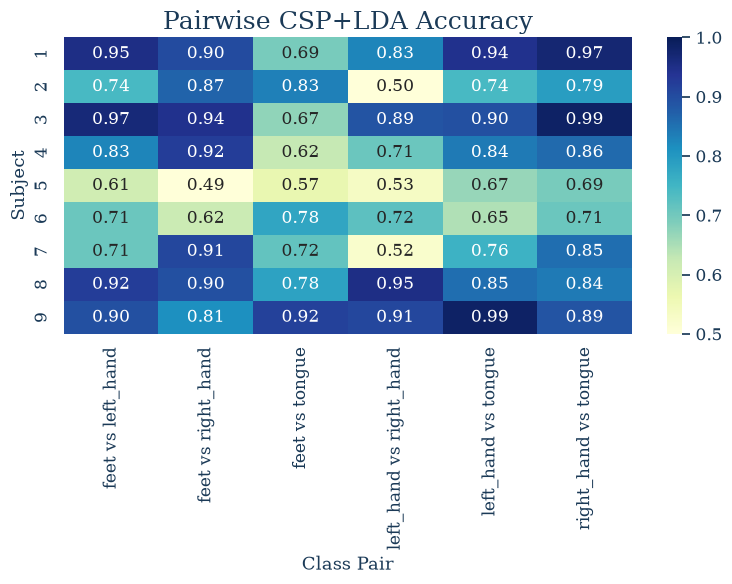

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

pivot = results.pivot(
    index="subject",
    columns="pair",
    values="accuracy",
)

plt.figure(figsize=(8,6))

sns.heatmap(
    pivot,
    annot=True,
    cmap="YlGnBu",
    vmin=0.5,
    vmax=1,
    fmt=".2f"
)

plt.title("Pairwise CSP+LDA Accuracy")
plt.xlabel("Class Pair")
plt.ylabel("Subject")

plt.tight_layout()
plt.show()

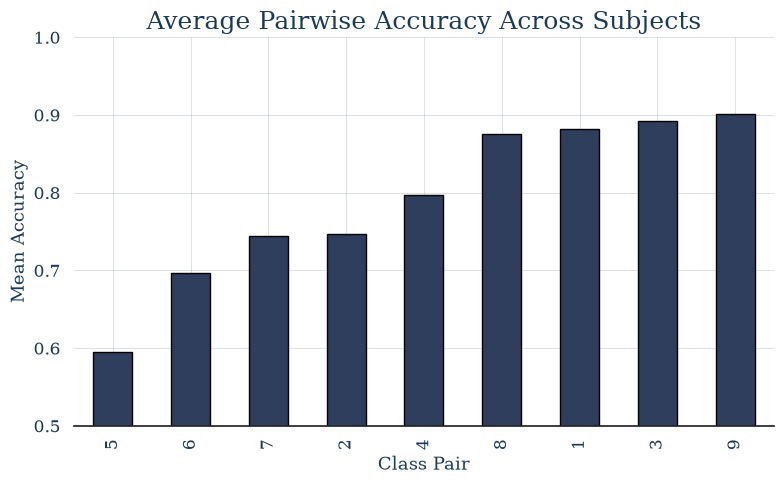

In [48]:
pair_mean = (
    results
    .groupby("subject")["accuracy"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(8,5))

pair_mean.plot(
    kind="bar",
    edgecolor="black"
)

plt.ylabel("Mean Accuracy")
plt.xlabel("Class Pair")
plt.title("Average Pairwise Accuracy Across Subjects")
plt.ylim(0.5, 1.0)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
from scipy.stats import friedmanchisquare


pair_mean = (
    results
    .groupby("pair")["accuracy"]
    .agg(["mean","std"])
)


pivot = results.pivot(
    index="subject",
    columns="pair",
    values="accuracy"
)

friedmanchisquare(
    *[pivot[col] for col in pivot.columns]
)



FriedmanchisquareResult(statistic=np.float64(4.5686900958466365), pvalue=np.float64(0.4707458731069666))

## collapse

In [37]:
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import numpy as np
import copy
import torch
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_auc_score, precision_score, recall_score, accuracy_score
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import numpy as np
import copy
import torch
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import pandas as pd

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
import numpy as np
import torch



batch_size = 32
num_epochs = 100
k = 9

params = ["acc", "auc", "fmeasure"]

patience = 15
min_delta = 1e-4
fold_results = []


def evaluate(model, X, Y, params, batch_size=64):
    was_training = model.training
    model.eval()

    all_probs = []
    all_preds = []

    with torch.no_grad():
        for s in range(0, len(X), batch_size):
            e = min(s + batch_size, len(X))

            inputs = torch.from_numpy(X[s:e]).float()

            inputs = inputs.cuda(0)

            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)

            all_probs.append(probs.cpu().numpy())
            all_preds.append(probs.argmax(dim=1).cpu().numpy())

    probs = np.concatenate(all_probs, axis=0)
    pred_labels = np.concatenate(all_preds, axis=0)


    results = []

    for param in params:
        if param == "acc":
            results.append(accuracy_score(Y, pred_labels))

        elif param == "auc":
            try:
                results.append(
                    roc_auc_score(
                        Y,
                        probs,
                        multi_class="ovo",
                        labels=np.arange(probs.shape[1])
                    )
                )
            except ValueError:
                results.append(None)

        elif param == "fmeasure":
            results.append(f1_score(Y, pred_labels, average="macro"))

    

    if was_training:
        model.train()
    else:
        model.eval()
    return results




class EEGNetTorch(nn.Module):
    """
    Input:
        (batch, 1, Chans, Samples)

    When CSP is used:
        Chans = number of CSP components
    """

    def __init__(
        self,
        nb_classes=4,
        Chans=8,
        Samples=1001,
        dropoutRate=0.5,
        kernLength=125,
        F1=8,
        D=2,
        F2=16,
    ):
        super().__init__()

        self.conv_temporal = nn.Conv2d(
            in_channels=1,
            out_channels=F1,
            kernel_size=(1, kernLength),
            padding="same",
            bias=False,
        )

        self.bn1 = nn.BatchNorm2d(
            F1,
            eps=1e-3,
            momentum=0.01,
        )

        # Spatial convolution now spans all CSP components
        self.conv_spatial = nn.Conv2d(
            in_channels=F1,
            out_channels=F1 * D,
            kernel_size=(Chans, 1),
            groups=F1,
            bias=False,
        )

        self.bn2 = nn.BatchNorm2d(
            F1 * D,
            eps=1e-3,
            momentum=0.01,
        )

        self.pool1 = nn.AvgPool2d(
            kernel_size=(1, 4)
        )

        self.drop1 = nn.Dropout(dropoutRate)

        self.sepConv = nn.Conv2d(
            in_channels=F1 * D,
            out_channels=F1 * D,
            kernel_size=(1, 16),
            padding="same",
            groups=F1 * D,
            bias=False,
        )

        self.sep_pointwise = nn.Conv2d(
            in_channels=F1 * D,
            out_channels=F2,
            kernel_size=(1, 1),
            bias=False,
        )

        self.bn3 = nn.BatchNorm2d(
            F2,
            eps=1e-3,
            momentum=0.01,
        )

        self.pool2 = nn.AvgPool2d(
            kernel_size=(1, 8)
        )

        self.drop2 = nn.Dropout(dropoutRate)

        with torch.no_grad():
            dummy = torch.zeros(
                1,
                1,
                Chans,
                Samples,
            )

            features = self._features(dummy)
            self.flatten_dim = features.flatten(1).shape[1]

        self.classifier = nn.Linear(
            self.flatten_dim,
            nb_classes,
        )

    def _features(self, x):
        x = self.conv_temporal(x)
        x = self.bn1(x)

        x = self.conv_spatial(x)
        x = self.bn2(x)
        x = F.elu(x)

        x = self.pool1(x)
        x = self.drop1(x)

        x = self.sepConv(x)
        x = self.sep_pointwise(x)
        x = self.bn3(x)
        x = F.elu(x)

        x = self.pool2(x)
        x = self.drop2(x)

        return x

    def forward(self, x):
        x = self._features(x)
        x = torch.flatten(x, start_dim=1)
        return self.classifier(x)


Fold 1/9 - Test subject: [1]
Early stopping at epoch 27
[[ 70  17   9  48]
 [  9 122  10   3]
 [  7  39  98   0]
 [ 59  17   0  68]]

Fold 1 Final Validation -
{'acc': 0.6215277777777778, 'auc': np.float64(0.873046875), 'fmeasure': 0.6180652995272952}

Fold 2/9 - Test subject: [2]
Early stopping at epoch 15
[[  1 140   1   2]
 [  1 138   0   5]
 [  0 143   0   1]
 [  0 143   0   1]]

Fold 2 Final Validation -
{'acc': 0.24305555555555555, 'auc': np.float64(0.4951995724022633), 'fmeasure': 0.1041502585090998}

Fold 3/9 - Test subject: [3]
Early stopping at epoch 44
[[ 69  12   9  54]
 [  5 110   1  28]
 [ 11   6  89  38]
 [  6   1   0 137]]

Fold 3 Final Validation -
{'acc': 0.703125, 'auc': np.float64(0.9278227880658436), 'fmeasure': 0.7022242267633517}

Fold 4/9 - Test subject: [4]
Early stopping at epoch 18
[[ 12  73  19  40]
 [  6 113  19   6]
 [  4  59  77   4]
 [ 11  60  32  41]]

Fold 4 Final Validation -
{'acc': 0.421875, 'auc': np.float64(0.7218806262860084), 'fmeasure': 0.3792

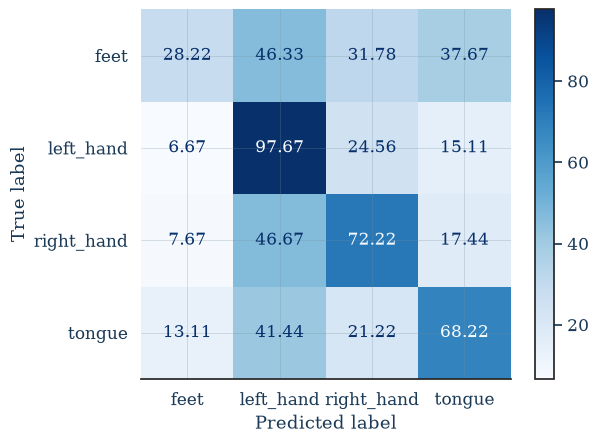

In [38]:

le = LabelEncoder()
batch_size=32
X_list = []
y_list = []
subjects_list = []

fold_results = []
fold_conf_mats = []
prediction_bias_rows = []
num_epochs = 60

for i in range(1, 10):
    Xi = np.load(fr"/home/hia2037/EEGMotorImagery-Classification/Data/X{i}.npy").astype(np.float32)
    Xi = Xi[:, None, :, :]

    yi = np.load(fr"/home/hia2037/EEGMotorImagery-Classification/Data/X{i}L.npy")

    X_list.append(Xi)
    y_list.append(yi)

    subjects_list.append(np.full(len(yi), i))

X = np.concatenate(X_list, axis=0)
y = np.concatenate(y_list, axis=0)
subjects = np.concatenate(subjects_list, axis=0)

le = LabelEncoder()
y_cv = le.fit_transform(y).astype(np.int64)
X_cv = X.astype(np.float32)

logo = LeaveOneGroupOut()
k = len(np.unique(subjects))

for fold, (train_idx, valid_idx) in enumerate(
    logo.split(X_cv, y_cv, groups=subjects),
    start=1
):
    test_subject = np.unique(subjects[valid_idx])
    print(f"\nFold {fold}/{k} - Test subject: {test_subject}")

    X_tr, X_va = X_cv[train_idx], X_cv[valid_idx]
    y_tr, y_va = y_cv[train_idx], y_cv[valid_idx]


    train_ds = TensorDataset(
        torch.tensor(X_tr, dtype=torch.float32),
        torch.tensor(y_tr, dtype=torch.long)
    )

    valid_ds = TensorDataset(
        torch.tensor(X_va, dtype=torch.float32),
        torch.tensor(y_va, dtype=torch.long)
    )

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    valid_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=False)

    net = EEGNetTorch(
        nb_classes=4,
        Chans=22,
        Samples=1001,
        kernLength=64,
        F1=32,
        D=4,
        F2=16,
        dropoutRate=0.4854763234903182,
    ).to(device)

    optimizer = torch.optim.Adam(
        net.parameters(),
        lr=0.0004102432506048275
    )

    criterion = torch.nn.CrossEntropyLoss()

    best_val_loss = float("inf")
    best_model_state = None
    epochs_without_improvement = 0

    for epoch in range(60):

        net.train()
        running_loss = 0.0
        n_seen = 0

        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad(set_to_none=True)
            outputs = net(inputs)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            n_seen += inputs.size(0)

        train_loss = running_loss / n_seen

        net.eval()
        val_loss = 0.0
        val_seen = 0

        with torch.no_grad():
            for inputs, labels in valid_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = net(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                val_seen += inputs.size(0)

        val_loss = val_loss / val_seen

        if val_loss < best_val_loss - min_delta:
            best_val_loss = val_loss
            best_model_state = copy.deepcopy(net.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

    if best_model_state is not None:
        net.load_state_dict(best_model_state)

    metrics = dict(zip(params, evaluate(net, X_va, y_va, params)))
    fold_results.append(metrics)

    net.eval()
    with torch.no_grad():
        X_tensor = torch.tensor(X_va, dtype=torch.float32).to(device)
        outputs = net(X_tensor)
        y_pred = torch.argmax(outputs, dim=1).cpu().numpy()
    
    # --------------------------------------------------------
    # Prediction-bias analysis
    # --------------------------------------------------------

    subject_id = int(test_subject[0])

    for class_idx, class_name in enumerate(le.classes_):
        predicted_count = np.sum(y_pred == class_idx)
        predicted_fraction = np.mean(y_pred == class_idx)

        true_count = np.sum(y_va == class_idx)
        true_fraction = np.mean(y_va == class_idx)

        prediction_bias_rows.append({
            "subject": subject_id,
            "class_index": class_idx,
            "class": class_name,
            "predicted_count": predicted_count,
            "predicted_fraction": predicted_fraction,
            "true_count": true_count,
            "true_fraction": true_fraction,
            "prediction_bias": predicted_fraction - true_fraction,
        })

    cm = confusion_matrix(y_va, y_pred, labels=[0, 1, 2, 3])
    print(cm)
    fold_conf_mats.append(cm)

    print(f"\nFold {fold} Final Validation -")
    print(metrics)


print("\n========== Cross-Validation Results ==========")

avg_metrics = {}
for metric in params:
    values = [result[metric] for result in fold_results]
    avg_metrics[metric] = {
        "mean": np.mean(values),
        "std": np.std(values)
    }
    print(f"{metric}: {np.mean(values):.4f} ± {np.std(values):.4f}")

avg_cm = np.mean(fold_conf_mats, axis=0)


print("\nAverage Normalized Confusion Matrix:")
print(avg_cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=avg_cm,
    display_labels=le.classes_
)

disp.plot(
    cmap="Blues",
    values_format=".2f"
)

plt.show()

In [39]:
# ============================================================
# Prediction-bias results
# ============================================================

prediction_bias_df = pd.DataFrame(prediction_bias_rows)

print("\n========== Prediction Bias by Subject ==========")
print(
    prediction_bias_df[
        [
            "subject",
            "class",
            "true_fraction",
            "predicted_fraction",
            "prediction_bias",
        ]
    ].round(4)
)


========== Prediction Bias by Subject ==========
    subject       class  true_fraction  predicted_fraction  prediction_bias
0         1        feet           0.25              0.2517           0.0017
1         1   left_hand           0.25              0.3385           0.0885
2         1  right_hand           0.25              0.2031          -0.0469
3         1      tongue           0.25              0.2066          -0.0434
4         2        feet           0.25              0.0035          -0.2465
5         2   left_hand           0.25              0.9792           0.7292
6         2  right_hand           0.25              0.0017          -0.2483
7         2      tongue           0.25              0.0156          -0.2344
8         3        feet           0.25              0.1580          -0.0920
9         3   left_hand           0.25              0.2240          -0.0260
10        3  right_hand           0.25              0.1719          -0.0781
11        3      tongue           0.25

In [40]:
predicted_fraction_table = prediction_bias_df.pivot(
    index="subject",
    columns="class",
    values="predicted_fraction",
)

print("\nPredicted class fractions:")
print(predicted_fraction_table.round(4))


Predicted class fractions:
class      feet  left_hand  right_hand  tongue
subject                                       
1        0.2517     0.3385      0.2031  0.2066
2        0.0035     0.9792      0.0017  0.0156
3        0.1580     0.2240      0.1719  0.4462
4        0.0573     0.5295      0.2552  0.1580
5        0.0000     0.5017      0.4983  0.0000
6        0.0938     0.1979      0.1823  0.5260
7        0.1024     0.3316      0.3750  0.1910
8        0.0920     0.2292      0.3924  0.2865
9        0.1111     0.2951      0.2604  0.3333


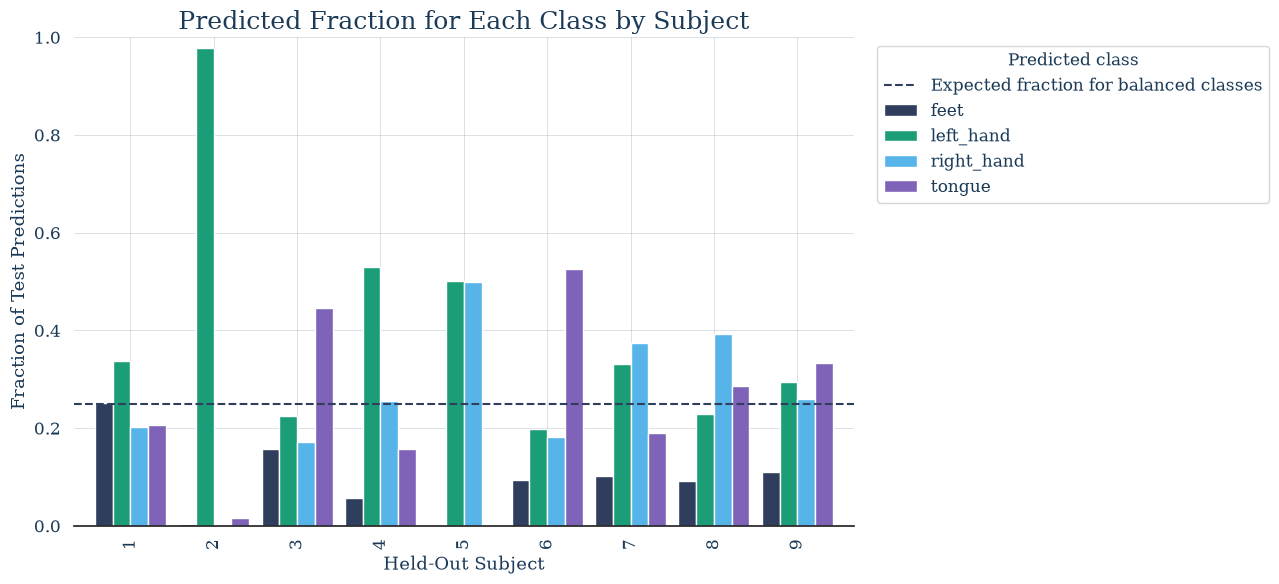

In [44]:
ax = predicted_fraction_table.plot(
    kind="bar",
    figsize=(13, 6),
    width=0.85,
)

ax.axhline(
    0.25,
    linestyle="--",
    linewidth=1.5,
    label="Expected fraction for balanced classes",
)

ax.set_title("Predicted Fraction for Each Class by Subject")
ax.set_xlabel("Held-Out Subject")
ax.set_ylabel("Fraction of Test Predictions")
ax.set_ylim(0, 1)

ax.legend(
    title="Predicted class",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## recall

In [49]:
from sklearn.metrics import classification_report

report = classification_report(
    y_va,
    y_pred,
    target_names=le.classes_,
    output_dict=True,
    zero_division=0,
)

print(pd.DataFrame(report).T)

              precision  recall  f1-score   support
feet             0.4688  0.2083    0.2885  144.0000
left_hand        0.6529  0.7708    0.7070  144.0000
right_hand       0.5200  0.5417    0.5306  144.0000
tongue           0.5729  0.7639    0.6548  144.0000
accuracy         0.5712  0.5712    0.5712    0.5712
macro avg        0.5537  0.5712    0.5452  576.0000
weighted avg     0.5537  0.5712    0.5452  576.0000


class    left_hand  right_hand   feet  tongue
subject                                      
S1           0.847       0.681  0.486   0.472
S2           0.958       0.000  0.007   0.007
S3           0.764       0.618  0.479   0.951
S4           0.785       0.535  0.083   0.285
S5           0.507       0.486  0.000   0.000
S6           0.271       0.250  0.062   0.590
S7           0.444       0.493  0.174   0.465
S8           0.757       0.910  0.264   0.729
S9           0.771       0.542  0.208   0.764


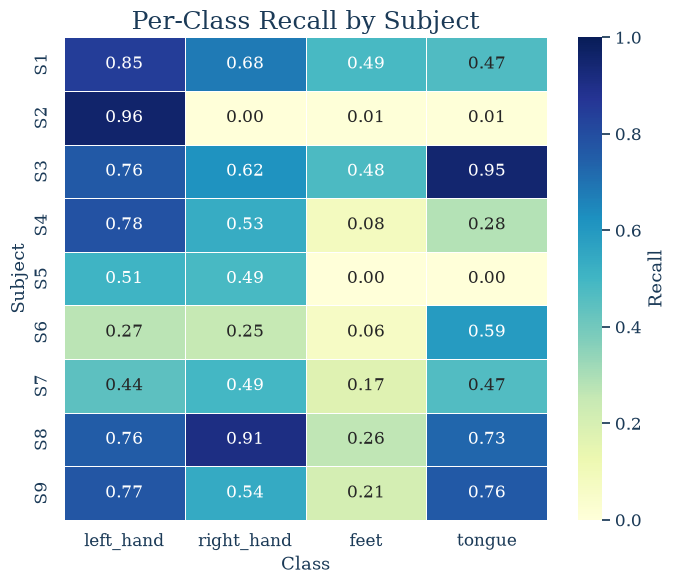

In [51]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

cms = {
    1: np.array([[70,17, 9,48],
                 [ 9,122,10, 3],
                 [ 7,39,98, 0],
                 [59,17, 0,68]]),

    2: np.array([[ 1,140, 1, 2],
                 [ 1,138, 0, 5],
                 [ 0,143, 0, 1],
                 [ 0,143, 0, 1]]),

    3: np.array([[69,12, 9,54],
                 [ 5,110,1,28],
                 [11, 6,89,38],
                 [ 6, 1, 0,137]]),

    4: np.array([[12,73,19,40],
                 [ 6,113,19, 6],
                 [ 4,59,77, 4],
                 [11,60,32,41]]),

    5: np.array([[ 0,65,79, 0],
                 [ 0,73,71, 0],
                 [ 0,74,70, 0],
                 [ 0,77,67, 0]]),

    6: np.array([[ 9,13,17,105],
                 [17,39,36,52],
                 [ 9,38,36,61],
                 [19,24,16,85]]),

    7: np.array([[25,46,64, 9],
                 [11,64,49,20],
                 [13,46,71,14],
                 [10,35,32,67]]),

    8: np.array([[38,18,56,32],
                 [ 8,109,8,19],
                 [ 2, 2,131,9],
                 [ 5, 3,31,105]]),

    9: np.array([[30,33,32,49],
                 [ 3,111,27, 3],
                 [23,13,78,30],
                 [ 8,13,13,110]])
}

classes = [ "feet", "left_hand", "right_hand", "tongue"]

rows = []

for subject, cm in cms.items():
    recall = np.diag(cm) / cm.sum(axis=1)

    for c, r in zip(classes, recall):
        rows.append({
            "subject": f"S{subject}",
            "class": c,
            "recall": r
        })

recall_df = pd.DataFrame(rows)

recall_table = recall_df.pivot(
    index="subject",
    columns="class",
    values="recall"
)

# Reorder columns
recall_table = recall_table[
    ["left_hand", "right_hand", "feet", "tongue"]
]

print(recall_table.round(3))

plt.figure(figsize=(7,6))

sns.heatmap(
    recall_table,
    annot=True,
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label":"Recall"}
)

plt.title("Per-Class Recall by Subject")
plt.xlabel("Class")
plt.ylabel("Subject")

plt.tight_layout()
plt.show()

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion-matrix row/column order from LabelEncoder:
# 0 = feet
# 1 = left_hand
# 2 = right_hand
# 3 = tongue

class_order = ["feet", "left_hand", "right_hand", "tongue"]

# ------------------------------------------------------------
# Extract where true feet trials were predicted
# ------------------------------------------------------------

feet_idx = class_order.index("feet")
rows = []

for subject, cm in cms.items():
    feet_counts = cm[feet_idx, :]
    feet_total = feet_counts.sum()
    feet_fractions = feet_counts / feet_total

    for predicted_class, count, fraction in zip(
        class_order,
        feet_counts,
        feet_fractions,
    ):
        rows.append({
            "subject": f"S{subject}",
            "predicted_class": predicted_class,
            "count": int(count),
            "fraction": fraction,
        })

feet_df = pd.DataFrame(rows)

feet_table = feet_df.pivot(
    index="subject",
    columns="predicted_class",
    values="fraction",
)

# Put the columns in a readable order
feet_table = feet_table[
    ["left_hand", "right_hand", "feet", "tongue"]
]

print("Distribution of predictions for true feet trials:")
print(feet_table.round(3))

Distribution of predictions for true feet trials:
predicted_class  left_hand  right_hand   feet  tongue
subject                                              
S1                   0.118       0.062  0.486   0.333
S2                   0.972       0.007  0.007   0.014
S3                   0.083       0.062  0.479   0.375
S4                   0.507       0.132  0.083   0.278
S5                   0.451       0.549  0.000   0.000
S6                   0.090       0.118  0.062   0.729
S7                   0.319       0.444  0.174   0.062
S8                   0.125       0.389  0.264   0.222
S9                   0.229       0.222  0.208   0.340


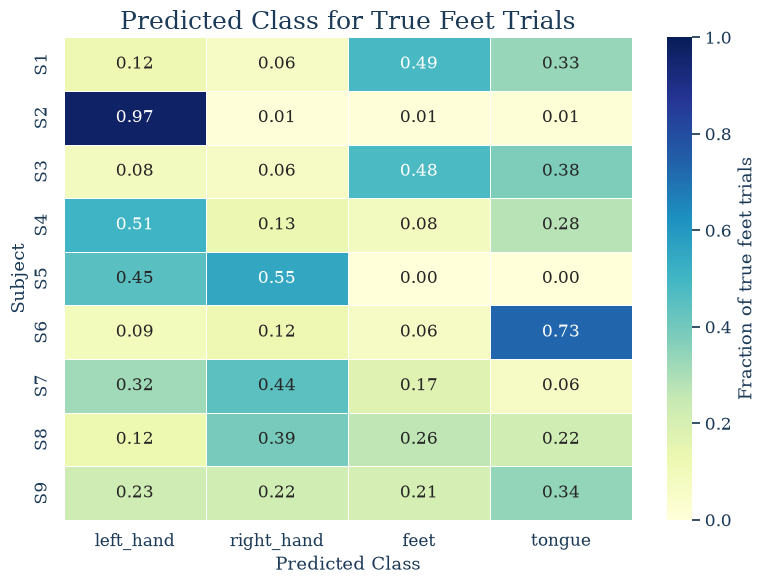

In [54]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    feet_table,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"label": "Fraction of true feet trials"},
)

plt.title("Predicted Class for True Feet Trials")
plt.xlabel("Predicted Class")
plt.ylabel("Subject")

plt.tight_layout()
plt.show()

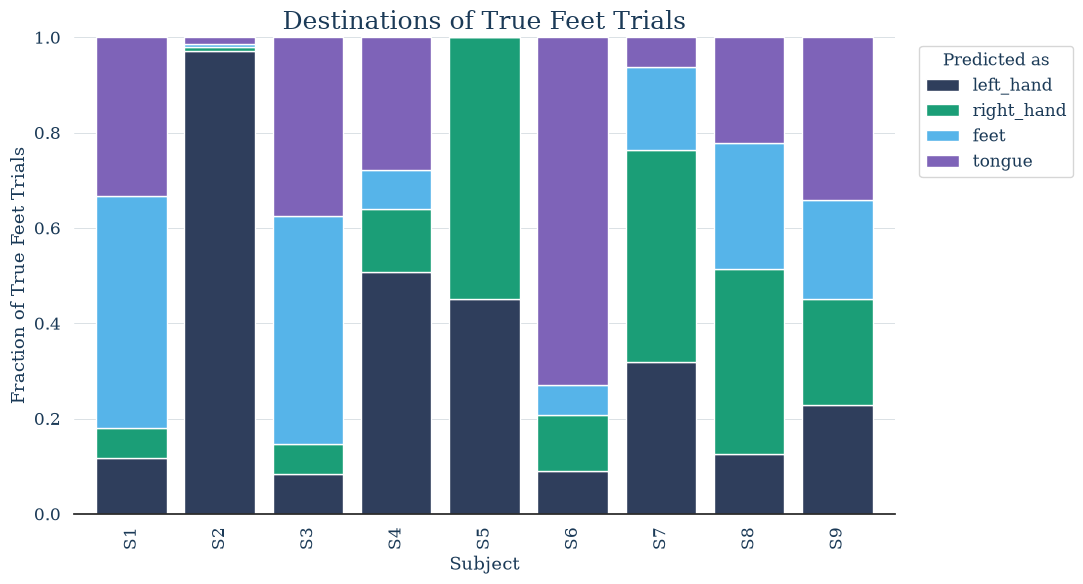

In [55]:
ax = feet_table.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 6),
    width=0.8,
)

ax.set_title("Destinations of True Feet Trials")
ax.set_xlabel("Subject")
ax.set_ylabel("Fraction of True Feet Trials")
ax.set_ylim(0, 1)

ax.legend(
    title="Predicted as",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()


Feet recall by subject:
subject
S1    0.486
S2    0.007
S3    0.479
S4    0.083
S5    0.000
S6    0.062
S7    0.174
S8    0.264
S9    0.208
Name: feet, dtype: float64


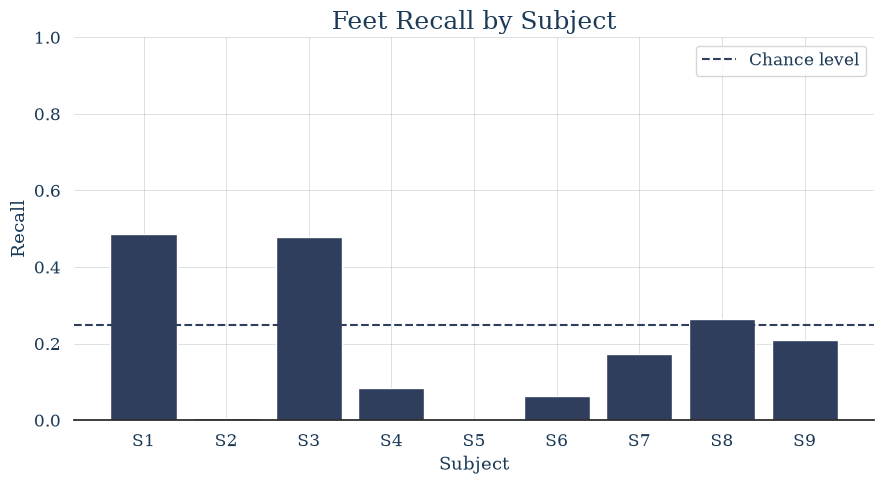

In [56]:
feet_recall = feet_table["feet"]

print("\nFeet recall by subject:")
print(feet_recall.round(3))

plt.figure(figsize=(9, 5))

plt.bar(
    feet_recall.index,
    feet_recall.values,
)

plt.axhline(
    0.25,
    linestyle="--",
    linewidth=1.5,
    label="Chance level",
)

plt.title("Feet Recall by Subject")
plt.xlabel("Subject")
plt.ylabel("Recall")
plt.ylim(0, 1)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## erd

In [57]:
import numpy as np
import matplotlib.pyplot as plt
import mne

from scipy.signal import butter, sosfiltfilt, hilbert
from moabb.datasets import BNCI2014_001
from moabb.paradigms import MotorImagery

In [60]:
import numpy as np
import pandas as pd
import mne

from moabb.datasets import BNCI2014_001


dataset = BNCI2014_001()
subjects = list(range(1, 10))

all_X = []
all_y = []
all_metadata = []

# Desired epoch relative to the motor-imagery cue
tmin = -1.0
tmax = 4.0
baseline = None

for subject in subjects:
    subject_data = dataset.get_data(subjects=[subject])

    # Structure:
    # subject_data[subject][session_name][run_name] = mne.io.Raw
    for session_name, runs in subject_data[subject].items():
        for run_name, raw in runs.items():
            raw = raw.copy().load_data()

            # Keep EEG channels
            raw.pick_types(
                eeg=True,
                eog=False,
                stim=False,
                exclude="bads",
            )

            # Optional filtering before epoching
            raw.filter(
                l_freq=4.0,
                h_freq=40.0,
                method="fir",
                verbose=False,
            )

            # MOABB datasets commonly store events as annotations
            events, annotation_event_id = (
                mne.events_from_annotations(
                    raw,
                    verbose=False,
                )
            )

            print(
                f"S{subject} | {session_name} | {run_name} | "
                f"events: {annotation_event_id}"
            )

            # Identify the four MI classes
            desired_classes = [
                "feet",
                "left_hand",
                "right_hand",
                "tongue",
            ]

            event_id = {}

            for class_name in desired_classes:
                if class_name in annotation_event_id:
                    event_id[class_name] = (
                        annotation_event_id[class_name]
                    )

            if len(event_id) != 4:
                print(
                    "Skipping run because all four classes "
                    "were not found."
                )
                continue

            epochs = mne.Epochs(
                raw,
                events,
                event_id=event_id,
                tmin=tmin,
                tmax=tmax,
                baseline=baseline,
                preload=True,
                reject_by_annotation=True,
                event_repeated="drop",
                verbose=False,
            )

            if len(epochs) == 0:
                continue

            X_run = epochs.get_data(
                picks="eeg",
                copy=True,
            )

            # Convert event codes back into class names
            inverse_event_id = {
                code: class_name
                for class_name, code in event_id.items()
            }

            y_run = np.array([
                inverse_event_id[event_code]
                for event_code in epochs.events[:, 2]
            ])

            run_metadata = pd.DataFrame({
                "subject": subject,
                "session": session_name,
                "run": run_name,
            }, index=np.arange(len(epochs)))

            all_X.append(X_run)
            all_y.append(y_run)
            all_metadata.append(run_metadata)


X = np.concatenate(all_X, axis=0)
y = np.concatenate(all_y, axis=0)
metadata = pd.concat(
    all_metadata,
    ignore_index=True,
)

sfreq = float(epochs.info["sfreq"])
times = epochs.times.copy()
info = epochs.info.copy()

print("\nFinal shape:", X.shape)
print("Classes:", np.unique(y))
print("Time range:", times[0], "to", times[-1])
print("Sampling frequency:", sfreq)
print(metadata.head())

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
S1 | 0train | 0 | events: {np.str_('feet'): 1, np.str_('left_hand'): 2, np.str_('right_hand'): 3, np.str_('tongue'): 4}
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
S1 | 0train | 1 | events: {np.str_('feet'): 1, np.str_('left_hand'): 2, np.str_('right_hand'): 3, np.str_('tongue'): 4}
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
S1 | 0train | 2 | events: {np.str_('feet'): 1, np.str_('left_hand'): 2, np.str_('right_hand'): 3, np.str_('tongue'): 4}
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
S1 | 0train | 3 | events: {np.str_('feet'): 1, np.str_('left_hand'): 2, np.str_('right_hand'): 3, np.str_('tongue'): 4}
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
S1 | 0train | 4 | events: {np.str_('feet'): 1, np.str_('left_hand'): 2, np.str_('right_hand'): 3, np.str_('tongue'): 4}
NOTE: pick_type

In [61]:
print(times[0], times[-1])

assert times[0] <= -0.8, (
    "The extracted epochs still do not contain "
    "the requested baseline."
)

baseline_mask = (
    (times >= -0.8) &
    (times <= -0.1)
)

imagery_mask = (
    (times >= 0.5) &
    (times <= 3.5)
)

print("Baseline samples:", baseline_mask.sum())
print("Imagery samples:", imagery_mask.sum())

-1.0 4.0
Baseline samples: 176
Imagery samples: 751


In [64]:
def compute_band_power(
    data,
    sfreq,
    fmin,
    fmax,
    filter_order=4,
):
    """
    Compute instantaneous power using band-pass filtering
    followed by the Hilbert transform.

    Parameters
    ----------
    data : ndarray, shape (trials, channels, samples)
    sfreq : float
    fmin, fmax : float

    Returns
    -------
    power : ndarray, shape (trials, channels, samples)
    """
    sos = butter(
        filter_order,
        [fmin, fmax],
        btype="bandpass",
        fs=sfreq,
        output="sos",
    )

    filtered = sosfiltfilt(
        sos,
        data,
        axis=-1,
    )

    analytic = hilbert(
        filtered,
        axis=-1,
    )

    return np.abs(analytic) ** 2

In [65]:
def compute_erd_ers_topography(
    data,
    times,
    sfreq,
    fmin,
    fmax,
    baseline=(-0.8, -0.1),
    imagery=(0.5, 3.5),
):
    """
    Compute trial-wise baseline-normalized ERD/ERS and
    average it over the imagery period.

    Returns
    -------
    erd_topography : ndarray, shape (channels,)
        Negative values indicate ERD.
        Positive values indicate ERS.
    trial_topographies : ndarray, shape (trials, channels)
    """
    baseline_mask = (
        (times >= baseline[0]) &
        (times <= baseline[1])
    )

    imagery_mask = (
        (times >= imagery[0]) &
        (times <= imagery[1])
    )

    if not baseline_mask.any():
        raise ValueError("Baseline window contains no samples.")

    if not imagery_mask.any():
        raise ValueError("Imagery window contains no samples.")

    power = compute_band_power(
        data=data,
        sfreq=sfreq,
        fmin=fmin,
        fmax=fmax,
    )

    # One baseline value per trial and channel
    baseline_power = power[..., baseline_mask].mean(
        axis=-1,
        keepdims=True,
    )

    # Signed percentage change
    erd_ers = 100.0 * (
        power - baseline_power
    ) / (baseline_power + np.finfo(float).eps)

    # Average over the imagery interval
    trial_topographies = erd_ers[..., imagery_mask].mean(
        axis=-1
    )

    # Average across trials
    erd_topography = trial_topographies.mean(axis=0)

    return erd_topography, trial_topographies

In [66]:
class_order = [
    "feet",
    "left_hand",
    "right_hand",
    "tongue",
]

bands = {
    "μ-band, 8–13 Hz": (8, 13),
    "β-band, 13–30 Hz": (13, 30),
}

erd_maps = {}
trial_maps = {}

for band_name, (fmin, fmax) in bands.items():
    erd_maps[band_name] = {}
    trial_maps[band_name] = {}

    for class_name in class_order:
        class_mask = y == class_name

        class_topography, class_trial_maps = (
            compute_erd_ers_topography(
                data=X[class_mask],
                times=times,
                sfreq=sfreq,
                fmin=fmin,
                fmax=fmax,
                baseline=(-0.8, -0.1),
                imagery=(0.5, 3.5),
            )
        )

        erd_maps[band_name][class_name] = class_topography
        trial_maps[band_name][class_name] = class_trial_maps

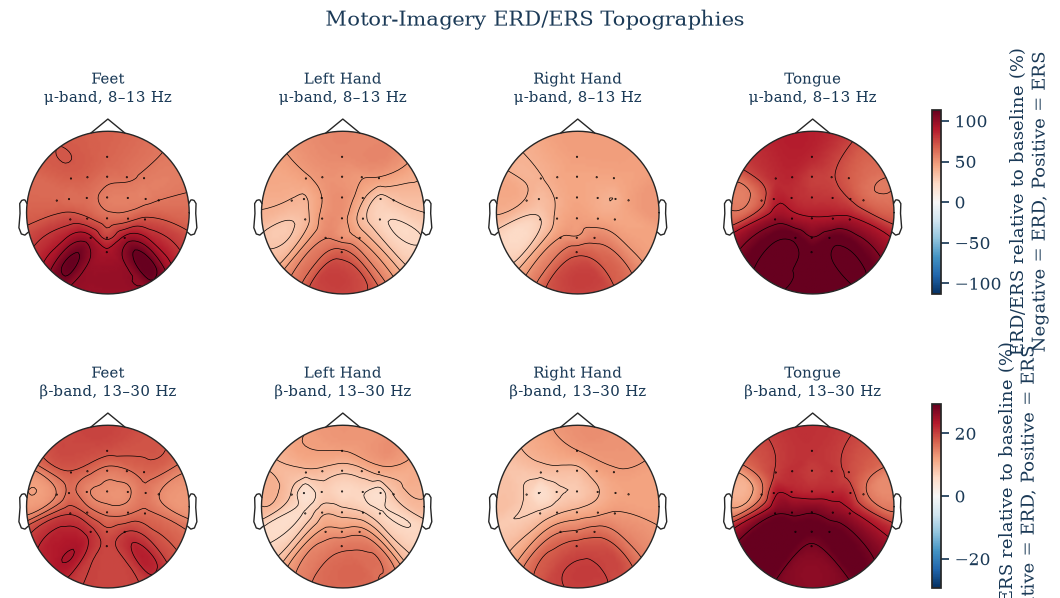

In [67]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=4,
    figsize=(14, 7),
)

for band_idx, (band_name, class_maps) in enumerate(
    erd_maps.items()
):
    all_values = np.concatenate(
        [
            class_maps[class_name].ravel()
            for class_name in class_order
        ]
    )

    # Symmetric range around zero
    limit = np.nanpercentile(
        np.abs(all_values),
        98,
    )

    for class_idx, class_name in enumerate(class_order):
        ax = axes[band_idx, class_idx]

        image, _ = mne.viz.plot_topomap(
            class_maps[class_name],
            info,
            axes=ax,
            show=False,
            cmap="RdBu_r",
            vlim=(-limit, limit),
            contours=6,
            sensors=True,
        )

        readable_name = class_name.replace("_", " ").title()

        ax.set_title(
            f"{readable_name}\n{band_name}",
            fontsize=11,
        )

    colorbar = fig.colorbar(
        image,
        ax=axes[band_idx, :],
        shrink=0.75,
        pad=0.02,
    )

    colorbar.set_label(
        "ERD/ERS relative to baseline (%)\n"
        "Negative = ERD, Positive = ERS"
    )

fig.suptitle(
    "Motor-Imagery ERD/ERS Topographies",
    fontsize=15,
)

plt.show()

In [68]:
subject_to_plot = 5

subject_mask = (
    metadata["subject"].to_numpy().astype(int)
    == subject_to_plot
)

X_subject = X[subject_mask]
y_subject = y[subject_mask]

subject_maps = {}

for band_name, (fmin, fmax) in bands.items():
    subject_maps[band_name] = {}

    for class_name in class_order:
        class_mask = y_subject == class_name

        topography, _ = compute_erd_ers_topography(
            data=X_subject[class_mask],
            times=times,
            sfreq=sfreq,
            fmin=fmin,
            fmax=fmax,
            baseline=(-0.8, -0.1),
            imagery=(0.5, 3.5),
        )

        subject_maps[band_name][class_name] = topography

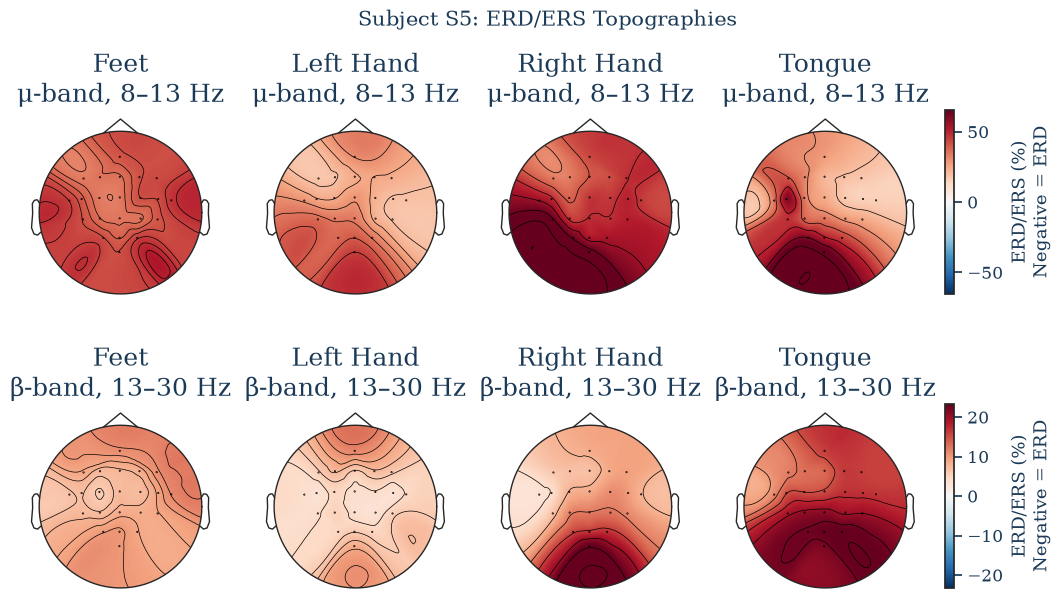

In [69]:
fig, axes = plt.subplots(
    2,
    4,
    figsize=(14, 7),
)

for band_idx, (band_name, class_maps) in enumerate(
    subject_maps.items()
):
    all_values = np.concatenate(
        [
            class_maps[class_name]
            for class_name in class_order
        ]
    )

    limit = np.nanpercentile(
        np.abs(all_values),
        98,
    )

    for class_idx, class_name in enumerate(class_order):
        ax = axes[band_idx, class_idx]

        image, _ = mne.viz.plot_topomap(
            class_maps[class_name],
            info,
            axes=ax,
            show=False,
            cmap="RdBu_r",
            vlim=(-limit, limit),
            contours=6,
            sensors=True,
        )

        ax.set_title(
            f"{class_name.replace('_', ' ').title()}\n"
            f"{band_name}"
        )

    colorbar = fig.colorbar(
        image,
        ax=axes[band_idx, :],
        shrink=0.75,
        pad=0.02,
    )

    colorbar.set_label(
        "ERD/ERS (%)\nNegative = ERD"
    )

fig.suptitle(
    f"Subject S{subject_to_plot}: ERD/ERS Topographies",
    fontsize=15,
)

plt.show()

In [70]:
central_names = [
    name for name in ["FCz", "Cz", "CPz"]
    if name in epochs.ch_names
]

central_indices = [
    epochs.ch_names.index(name)
    for name in central_names
]

print("Central channels used:", central_names)

Central channels used: ['FCz', 'Cz', 'CPz']


In [71]:
summary_rows = []

for subject in subjects:
    subject_mask = (
        metadata["subject"].to_numpy().astype(int)
        == subject
    )

    X_subject = X[subject_mask]
    y_subject = y[subject_mask]

    for band_name, (fmin, fmax) in bands.items():
        for class_name in class_order:
            class_mask = y_subject == class_name

            topography, trial_topographies = (
                compute_erd_ers_topography(
                    data=X_subject[class_mask],
                    times=times,
                    sfreq=sfreq,
                    fmin=fmin,
                    fmax=fmax,
                    baseline=(-0.8, -0.1),
                    imagery=(0.5, 3.5),
                )
            )

            central_values = trial_topographies[
                :,
                central_indices,
            ].mean(axis=1)

            summary_rows.append({
                "subject": subject,
                "class": class_name,
                "band": band_name,
                "mean_central_erd_ers": (
                    central_values.mean()
                ),
                "std_central_erd_ers": (
                    central_values.std(ddof=1)
                ),
            })

In [72]:
import pandas as pd

erd_summary = pd.DataFrame(summary_rows)

print(
    erd_summary.pivot_table(
        index="subject",
        columns=["band", "class"],
        values="mean_central_erd_ers",
    ).round(2)
)

band    β-band, 13–30 Hz                             μ-band, 8–13 Hz                             
class               feet left_hand right_hand tongue            feet left_hand right_hand  tongue
subject                                                                                          
1                  16.96      8.38       9.12  18.14           54.54     25.57      16.21   92.71
2                  26.15     21.36      18.17  17.74          105.17    103.86      74.83   92.13
3                  21.11     10.48       9.67  35.90           67.30     35.63      35.70   90.86
4                  34.56     12.71      18.01  45.04           82.12     63.16      39.94   78.15
5                   7.94      4.59       9.25  16.55           34.85     28.93      45.01   27.02
6                  26.58     15.65      18.43  17.46          132.92    106.67      90.51  113.20
7                 -15.88     -5.91      -6.29   7.37           11.05     29.93      15.55   28.37
8                  1

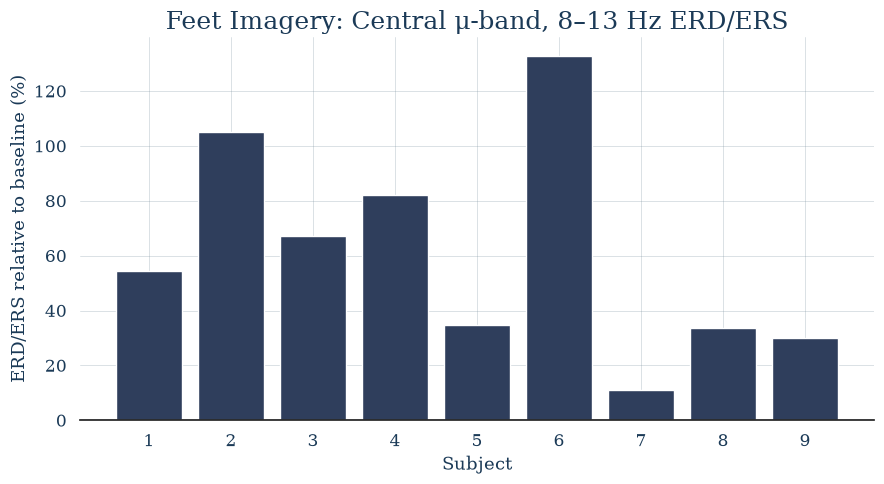

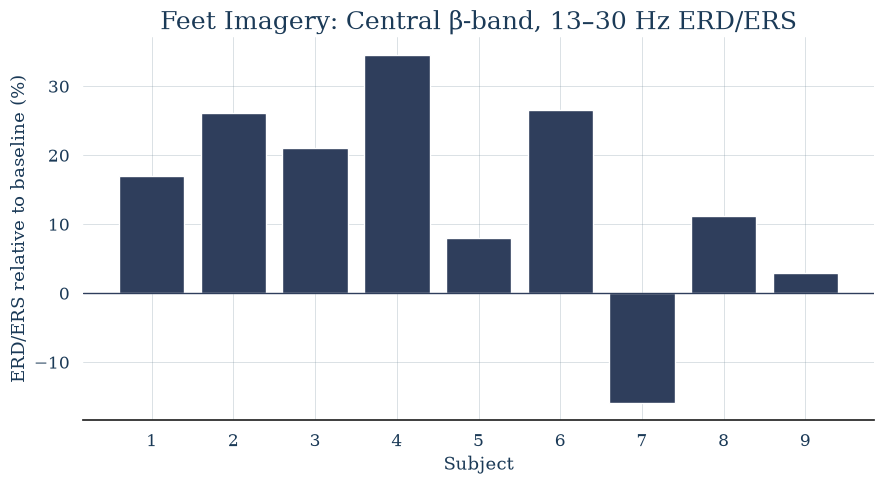

In [73]:
feet_summary = erd_summary[
    erd_summary["class"] == "feet"
]

for band_name in bands:
    plot_data = feet_summary[
        feet_summary["band"] == band_name
    ].sort_values("subject")

    plt.figure(figsize=(9, 5))

    plt.bar(
        plot_data["subject"].astype(str),
        plot_data["mean_central_erd_ers"],
    )

    plt.axhline(
        0,
        linewidth=1,
    )

    plt.xlabel("Subject")
    plt.ylabel("ERD/ERS relative to baseline (%)")
    plt.title(
        f"Feet Imagery: Central {band_name} ERD/ERS"
    )

    plt.grid(
        axis="y",
        alpha=0.3,
    )

    plt.tight_layout()
    plt.show()

## erd variability

In [74]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import pearsonr, friedmanchisquare

In [75]:
class_order = [
    "feet",
    "left_hand",
    "right_hand",
    "tongue",
]

bands = {
    "mu": (8, 13),
    "beta": (13, 30),
}

subject_ids = sorted(
    metadata["subject"].astype(int).unique()
)

subject_erd_maps = {}

for band_name, (fmin, fmax) in bands.items():
    subject_erd_maps[band_name] = {}

    for class_name in class_order:
        subject_erd_maps[band_name][class_name] = {}

        for subject in subject_ids:
            subject_mask = (
                metadata["subject"].astype(int).to_numpy()
                == subject
            )

            class_mask = y == class_name
            selection = subject_mask & class_mask

            if selection.sum() == 0:
                continue

            topography, trial_topographies = (
                compute_erd_ers_topography(
                    data=X[selection],
                    times=times,
                    sfreq=sfreq,
                    fmin=fmin,
                    fmax=fmax,
                    baseline=(-0.8, -0.1),
                    imagery=(0.5, 3.5),
                )
            )

            subject_erd_maps[band_name][class_name][
                subject
            ] = topography

In [76]:
correlation_rows = []

for band_name in bands:
    for class_name in class_order:
        class_maps = subject_erd_maps[
            band_name
        ][class_name]

        available_subjects = sorted(
            class_maps.keys()
        )

        for subject_a, subject_b in itertools.combinations(
            available_subjects,
            2,
        ):
            map_a = np.asarray(
                class_maps[subject_a]
            ).ravel()

            map_b = np.asarray(
                class_maps[subject_b]
            ).ravel()

            valid = (
                np.isfinite(map_a)
                & np.isfinite(map_b)
            )

            if valid.sum() < 3:
                correlation = np.nan
            elif np.std(map_a[valid]) == 0:
                correlation = np.nan
            elif np.std(map_b[valid]) == 0:
                correlation = np.nan
            else:
                correlation, _ = pearsonr(
                    map_a[valid],
                    map_b[valid],
                )

            correlation_rows.append({
                "band": band_name,
                "class": class_name,
                "subject_a": subject_a,
                "subject_b": subject_b,
                "pair": f"S{subject_a}-S{subject_b}",
                "map_correlation": correlation,
            })

correlation_df = pd.DataFrame(
    correlation_rows
)

print(correlation_df.head())

  band class  subject_a  subject_b   pair  map_correlation
0   mu  feet          1          2  S1-S2          -0.0106
1   mu  feet          1          3  S1-S3           0.5197
2   mu  feet          1          4  S1-S4           0.2756
3   mu  feet          1          5  S1-S5           0.2623
4   mu  feet          1          6  S1-S6           0.5761


In [77]:
correlation_summary = (
    correlation_df
    .groupby(["band", "class"])[
        "map_correlation"
    ]
    .agg(["mean", "std", "median", "count"])
    .reset_index()
)

print(
    correlation_summary.round(4)
)

   band       class    mean     std  median  count
0  beta        feet  0.0309  0.3973  0.0586     36
1  beta   left_hand  0.1613  0.3982  0.1693     36
2  beta  right_hand  0.2749  0.3394  0.3182     36
3  beta      tongue  0.2967  0.4428  0.4382     36
4    mu        feet  0.1883  0.3312  0.1888     36
5    mu   left_hand  0.1995  0.5005  0.3136     36
6    mu  right_hand  0.0052  0.3960  0.0137     36
7    mu      tongue  0.2847  0.4176  0.4049     36


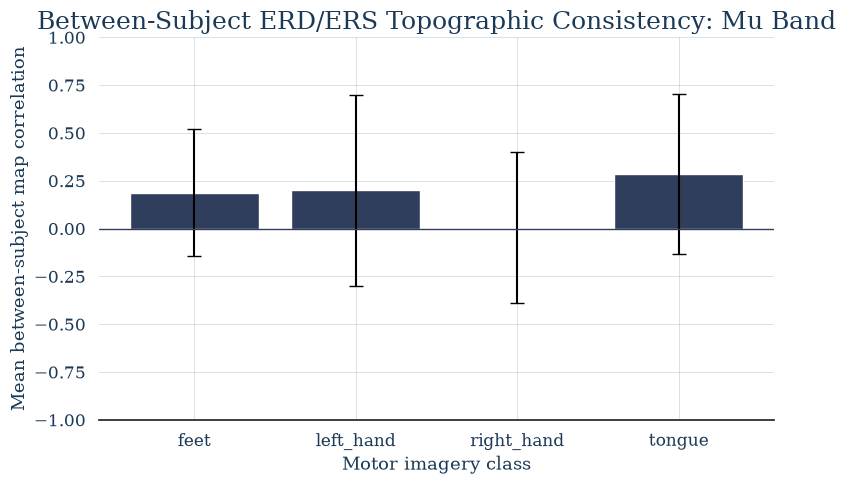

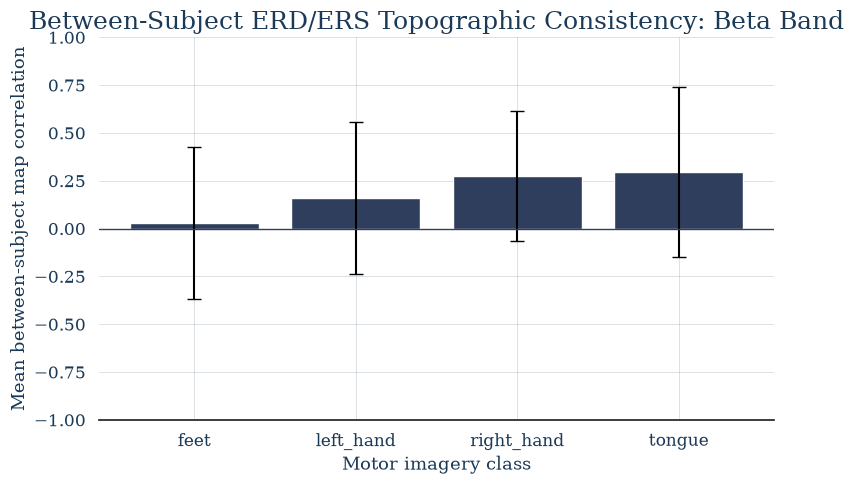

In [78]:
for band_name in bands:
    plot_data = (
        correlation_summary[
            correlation_summary["band"]
            == band_name
        ]
        .set_index("class")
        .reindex(class_order)
    )

    fig, ax = plt.subplots(
        figsize=(8, 5)
    )

    ax.bar(
        plot_data.index,
        plot_data["mean"],
        yerr=plot_data["std"],
        capsize=5,
    )

    ax.axhline(
        0,
        linewidth=1,
    )

    ax.set_ylim(-1, 1)
    ax.set_xlabel("Motor imagery class")
    ax.set_ylabel(
        "Mean between-subject map correlation"
    )
    ax.set_title(
        f"Between-Subject ERD/ERS "
        f"Topographic Consistency: "
        f"{band_name.capitalize()} Band"
    )
    ax.grid(
        axis="y",
        alpha=0.3,
    )

    plt.tight_layout()
    plt.show()

In [79]:
def create_subject_correlation_matrix(
    maps_by_subject,
):
    subjects = sorted(
        maps_by_subject.keys()
    )

    matrix = np.full(
        (len(subjects), len(subjects)),
        np.nan,
    )

    for i, subject_a in enumerate(subjects):
        for j, subject_b in enumerate(subjects):
            map_a = np.asarray(
                maps_by_subject[subject_a]
            ).ravel()

            map_b = np.asarray(
                maps_by_subject[subject_b]
            ).ravel()

            valid = (
                np.isfinite(map_a)
                & np.isfinite(map_b)
            )

            if subject_a == subject_b:
                matrix[i, j] = 1.0
            elif (
                valid.sum() >= 3
                and np.std(map_a[valid]) > 0
                and np.std(map_b[valid]) > 0
            ):
                matrix[i, j] = np.corrcoef(
                    map_a[valid],
                    map_b[valid],
                )[0, 1]

    return subjects, matrix

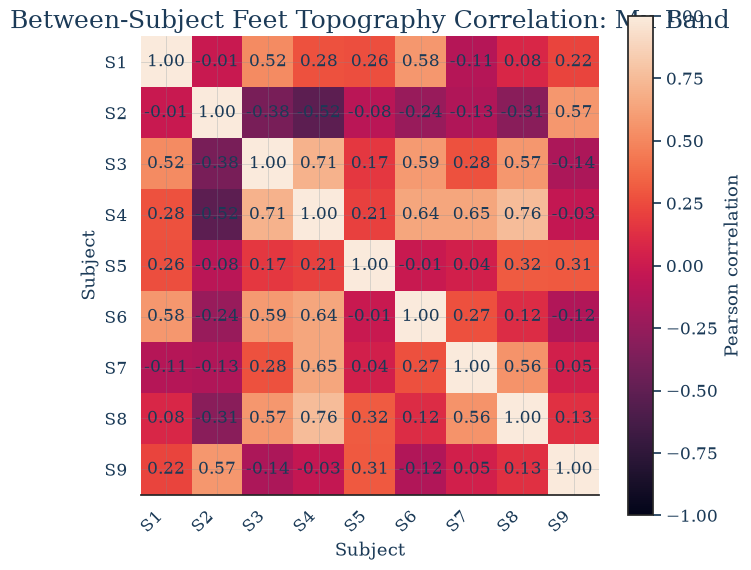

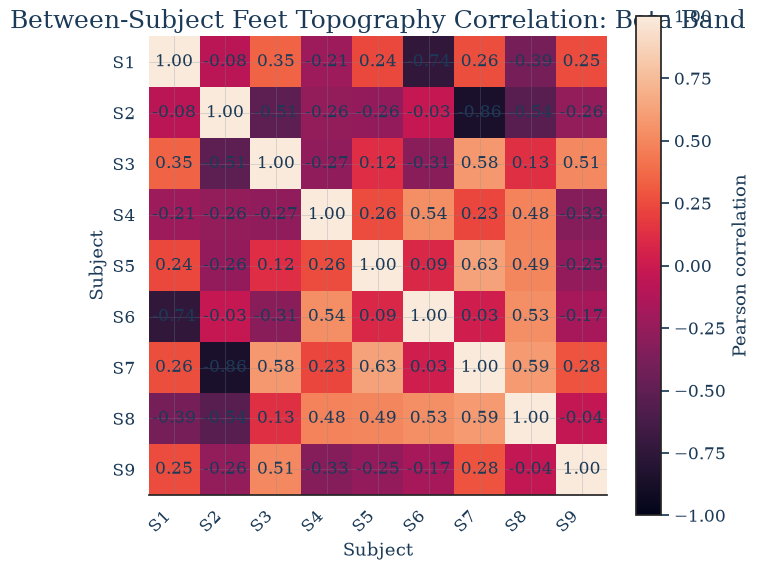

In [80]:
for band_name in bands:
    subjects_for_plot, feet_corr_matrix = (
        create_subject_correlation_matrix(
            subject_erd_maps[
                band_name
            ]["feet"]
        )
    )

    fig, ax = plt.subplots(
        figsize=(7, 6)
    )

    image = ax.imshow(
        feet_corr_matrix,
        vmin=-1,
        vmax=1,
        aspect="equal",
    )

    ax.set_xticks(
        np.arange(len(subjects_for_plot))
    )
    ax.set_yticks(
        np.arange(len(subjects_for_plot))
    )

    ax.set_xticklabels(
        [f"S{s}" for s in subjects_for_plot],
        rotation=45,
        ha="right",
    )
    ax.set_yticklabels(
        [f"S{s}" for s in subjects_for_plot]
    )

    for row in range(
        feet_corr_matrix.shape[0]
    ):
        for col in range(
            feet_corr_matrix.shape[1]
        ):
            value = feet_corr_matrix[
                row,
                col,
            ]

            if np.isfinite(value):
                ax.text(
                    col,
                    row,
                    f"{value:.2f}",
                    ha="center",
                    va="center",
                )

    colorbar = fig.colorbar(
        image,
        ax=ax,
    )
    colorbar.set_label(
        "Pearson correlation"
    )

    ax.set_title(
        f"Between-Subject Feet "
        f"Topography Correlation: "
        f"{band_name.capitalize()} Band"
    )

    ax.set_xlabel("Subject")
    ax.set_ylabel("Subject")

    plt.tight_layout()
    plt.show()

In [81]:
subject_consistency_rows = []

for band_name in bands:
    for class_name in class_order:
        class_maps = subject_erd_maps[
            band_name
        ][class_name]

        subjects_available = sorted(
            class_maps.keys()
        )

        for subject in subjects_available:
            subject_correlations = []

            for other_subject in subjects_available:
                if other_subject == subject:
                    continue

                map_a = np.asarray(
                    class_maps[subject]
                ).ravel()

                map_b = np.asarray(
                    class_maps[other_subject]
                ).ravel()

                valid = (
                    np.isfinite(map_a)
                    & np.isfinite(map_b)
                )

                if (
                    valid.sum() >= 3
                    and np.std(map_a[valid]) > 0
                    and np.std(map_b[valid]) > 0
                ):
                    r = np.corrcoef(
                        map_a[valid],
                        map_b[valid],
                    )[0, 1]

                    subject_correlations.append(r)

            subject_consistency_rows.append({
                "subject": subject,
                "band": band_name,
                "class": class_name,
                "mean_correlation_with_others": (
                    np.mean(subject_correlations)
                    if subject_correlations
                    else np.nan
                ),
            })

subject_consistency_df = pd.DataFrame(
    subject_consistency_rows
)

print(
    subject_consistency_df.round(4)
)

    subject  band       class  mean_correlation_with_others
0         1    mu        feet                        0.2276
1         2    mu        feet                       -0.1379
2         3    mu        feet                        0.2881
3         4    mu        feet                        0.3357
4         5    mu        feet                        0.1513
5         6    mu        feet                        0.2276
6         7    mu        feet                        0.2009
7         8    mu        feet                        0.2786
8         9    mu        feet                        0.1225
9         1    mu   left_hand                        0.3329
10        2    mu   left_hand                       -0.3010
11        3    mu   left_hand                        0.3473
12        4    mu   left_hand                        0.0013
13        5    mu   left_hand                        0.1696
14        6    mu   left_hand                        0.2751
15        7    mu   left_hand           

In [82]:
from scipy.stats import spearmanr, pearsonr

feet_recall_df = pd.DataFrame({
    "subject": [1, 2, 3, 4, 5, 6, 7, 8, 9],
    "feet_recall": [
        0.486,
        0.007,
        0.479,
        0.083,
        0.000,
        0.062,
        0.174,
        0.264,
        0.208,
    ],
})

feet_consistency = (
    subject_consistency_df[
        subject_consistency_df["class"]
        == "feet"
    ]
    .merge(
        feet_recall_df,
        on="subject",
        how="inner",
    )
)

print(
    feet_consistency.round(4)
)

    subject  band class  mean_correlation_with_others  feet_recall
0         1    mu  feet                        0.2276        0.486
1         2    mu  feet                       -0.1379        0.007
2         3    mu  feet                        0.2881        0.479
3         4    mu  feet                        0.3357        0.083
4         5    mu  feet                        0.1513        0.000
5         6    mu  feet                        0.2276        0.062
6         7    mu  feet                        0.2009        0.174
7         8    mu  feet                        0.2786        0.264
8         9    mu  feet                        0.1225        0.208
9         1  beta  feet                       -0.0404        0.486
10        2  beta  feet                       -0.3492        0.007
11        3  beta  feet                        0.0765        0.479
12        4  beta  feet                        0.0549        0.083
13        5  beta  feet                        0.1654        0

In [83]:
for band_name in bands:
    band_data = feet_consistency[
        feet_consistency["band"]
        == band_name
    ].dropna()

    pearson_r, pearson_p = pearsonr(
        band_data[
            "mean_correlation_with_others"
        ],
        band_data["feet_recall"],
    )

    spearman_r, spearman_p = spearmanr(
        band_data[
            "mean_correlation_with_others"
        ],
        band_data["feet_recall"],
    )

    print(
        f"\n{band_name.capitalize()} band"
    )
    print(
        f"Pearson: r={pearson_r:.4f}, "
        f"p={pearson_p:.4f}"
    )
    print(
        f"Spearman: rho={spearman_r:.4f}, "
        f"p={spearman_p:.4f}"
    )


Mu band
Pearson: r=0.4444, p=0.2307
Spearman: rho=0.5000, p=0.1705

Beta band
Pearson: r=0.1773, p=0.6481
Spearman: rho=-0.0333, p=0.9322


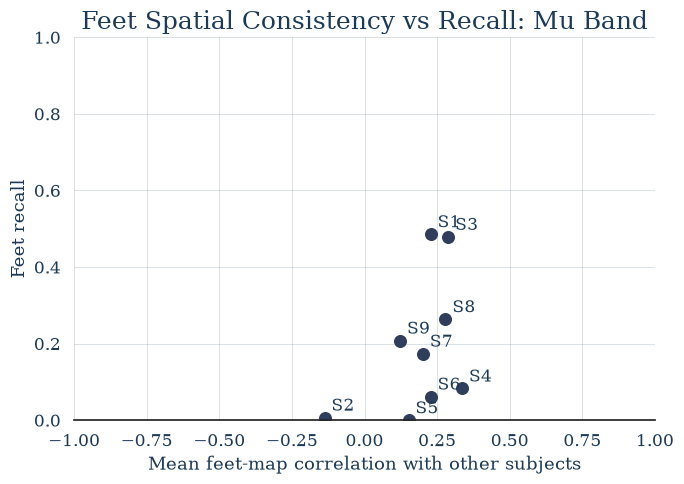

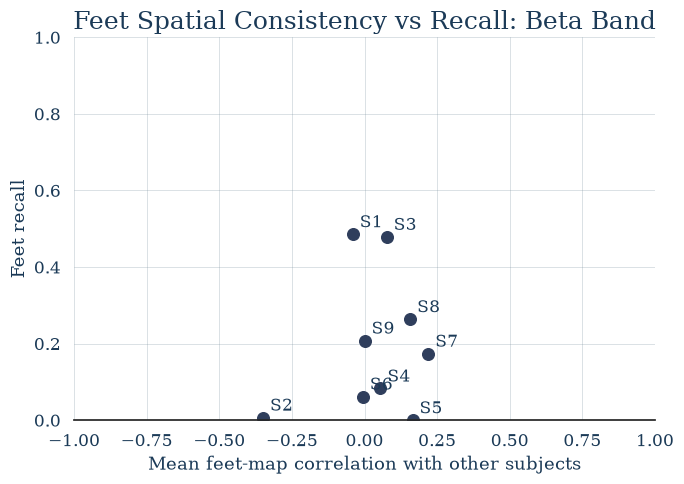

In [84]:
for band_name in bands:
    band_data = feet_consistency[
        feet_consistency["band"]
        == band_name
    ].dropna()

    fig, ax = plt.subplots(
        figsize=(7, 5)
    )

    ax.scatter(
        band_data[
            "mean_correlation_with_others"
        ],
        band_data["feet_recall"],
        s=70,
    )

    for _, row in band_data.iterrows():
        ax.annotate(
            f"S{int(row['subject'])}",
            (
                row[
                    "mean_correlation_with_others"
                ],
                row["feet_recall"],
            ),
            xytext=(5, 5),
            textcoords="offset points",
        )

    ax.set_xlabel(
        "Mean feet-map correlation "
        "with other subjects"
    )
    ax.set_ylabel("Feet recall")
    ax.set_title(
        f"Feet Spatial Consistency vs Recall: "
        f"{band_name.capitalize()} Band"
    )
    ax.set_xlim(-1, 1)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

In [85]:
for band_name in bands:
    consistency_table = (
        subject_consistency_df[
            subject_consistency_df["band"]
            == band_name
        ]
        .pivot(
            index="subject",
            columns="class",
            values=(
                "mean_correlation_with_others"
            ),
        )
        .reindex(columns=class_order)
        .dropna()
    )

    statistic, p_value = friedmanchisquare(
        consistency_table["feet"],
        consistency_table["left_hand"],
        consistency_table["right_hand"],
        consistency_table["tongue"],
    )

    print(
        f"{band_name.capitalize()} band: "
        f"Friedman chi-square="
        f"{statistic:.4f}, "
        f"p={p_value:.4f}"
    )

Mu band: Friedman chi-square=8.0667, p=0.0447
Beta band: Friedman chi-square=11.2667, p=0.0104


In [87]:
import itertools
import pandas as pd

from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

class_order = [
    "feet",
    "left_hand",
    "right_hand",
    "tongue",
]

posthoc_rows = []

for band_name in ["mu", "beta"]:
    table = (
        subject_consistency_df[
            subject_consistency_df["band"] == band_name
        ]
        .pivot(
            index="subject",
            columns="class",
            values="mean_correlation_with_others",
        )
        .reindex(columns=class_order)
        .dropna()
    )

    band_rows = []

    for class_a, class_b in itertools.combinations(class_order, 2):
        differences = table[class_a] - table[class_b]

        statistic, p_value = wilcoxon(
            table[class_a],
            table[class_b],
            alternative="two-sided",
            zero_method="wilcox",
        )

        band_rows.append({
            "band": band_name,
            "class_a": class_a,
            "class_b": class_b,
            "mean_a": table[class_a].mean(),
            "mean_b": table[class_b].mean(),
            "mean_difference": differences.mean(),
            "wilcoxon_statistic": statistic,
            "p_uncorrected": p_value,
        })

    corrected = multipletests(
        [row["p_uncorrected"] for row in band_rows],
        alpha=0.05,
        method="holm",
    )

    for row, adjusted_p, reject in zip(
        band_rows,
        corrected[1],
        corrected[0],
    ):
        row["p_holm"] = adjusted_p
        row["significant_holm"] = reject
        posthoc_rows.append(row)

posthoc_df = pd.DataFrame(posthoc_rows)

print(
    posthoc_df[
        [
            "band",
            "class_a",
            "class_b",
            "mean_a",
            "mean_b",
            "mean_difference",
            "p_uncorrected",
            "p_holm",
            "significant_holm",
        ]
    ].round(4)
)

    band     class_a     class_b  mean_a  mean_b  mean_difference  p_uncorrected  p_holm  significant_holm
0     mu        feet   left_hand  0.1883  0.1995          -0.0113         0.4961  0.4961             False
1     mu        feet  right_hand  0.1883  0.0052           0.1831         0.0117  0.0703             False
2     mu        feet      tongue  0.1883  0.2847          -0.0964         0.1641  0.4922             False
3     mu   left_hand  right_hand  0.1995  0.0052           0.1944         0.0547  0.2188             False
4     mu   left_hand      tongue  0.1995  0.2847          -0.0851         0.2031  0.4922             False
5     mu  right_hand      tongue  0.0052  0.2847          -0.2795         0.0195  0.0977             False
6   beta        feet   left_hand  0.0309  0.1613          -0.1304         0.0078  0.0469              True
7   beta        feet  right_hand  0.0309  0.2749          -0.2440         0.0078  0.0469              True
8   beta        feet      tongue  0.0